### Analyse av dag-data

- Les inn data
- Aggreger opp til dagsnivå
- Join med info df
- 

### Imports/ Snowflake session

In [148]:
from snowflake.snowpark.functions import col, sum as sum_, max as max_, datediff, round as round_, year, month, when, lit, lag, avg, count, stddev, to_date, dayofweek, weekofyear, dayofmonth, quarter, last_day
from snowflake.snowpark import Window
import re
import pandas as pd
import plotly.graph_objects as go
import numpy as np

# from dwh_tools.get_or_create_session import get_or_create_session
from snowflake.snowpark import Session
from snowflake.snowpark.context import get_active_session
import os
import requests
import gzip
import json
# from dwh_tools.get_or_create_session import get_or_create_session
pd.set_option('display.max_columns', None)
import time
import pywin
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [149]:
def get_or_create_session(schema: str = None) -> Session:
    """
    Returns the active Snowpark session if running inside Snowflake,
    otherwise creates one locally using Azure OAuth (interactive login if needed).
 
    Parameters
    ----------
    config_path : str
        Path to a JSON config file containing Snowflake connection parameters
        (account, warehouse, role, database, schema).
 
    Returns
    -------
    Session
        A Snowpark Session object.
    """
    # If running on snowflake
    if 'POSIT_PRODUCT' in os.environ:
        session = Session.builder.getOrCreate()
        session.sql("USE DATABASE PROD_FOR_SKADE_PRODUKT_ADHOC").collect()
        if schema:
            session.sql("USE SCHEMA " + schema).collect()
        else:
            session.sql("USE SCHEMA PRODUKT_WRITE_DEV").collect()
        session.sql("USE WAREHOUSE SKADE_VWH").collect()
 
        return session
 
    try:
        session = get_active_session()
        return session
    except Exception:
        import win32api
        if schema is None:
            schema = 'PRODUKT_WRITE_DEV'
 
        connection_parameters = {
            "server": "km28161.west-europe.azure.snowflakecomputing.com",
            "warehouse": "SKADE_VWH",
            "account": "VK82539-KLP",
            "database": "PROD_FOR_SKADE_PRODUKT_ADHOC",
            "schema" : schema,
            "user": win32api.GetUserNameEx(win32api.NameUserPrincipal),  
            "authenticator": "externalbrowser"
        }
       
        # Create the session
        session = Session.builder.configs(connection_parameters).create()
        return session

In [150]:
session = get_or_create_session()

### Les data

In [151]:
# Kundesenter data
df = session.table('elh_write.inngangsdata').to_pandas()
df.columns = df.columns.str.lower()
# TIA data
df_info = session.table('inngangsdata_info').to_pandas()
df_info.columns = df_info.columns.str.lower()

In [152]:
df.head()

,unique_id,forste_kogruppe,forste_ko,kunde,ankomst_dato,tid_i_ko,behandlet,behandlingstid,etterbehandlingstid,behandlingstid_etterbehandlingstid,overfort_eksternt,arbeidsplass,agent_id,god_reserve
0,3051408,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,99525091,02.06.2026 15:57:52,3,Behandlet,01:32,01:29,03:01,None,wp3409,lni,God agent
1,3051415,SK_Salg_Ny_PM,SK_Salg_Ny_PM_Tlf,0046707954838,02.06.2026 15:57:37,16,Behandlet,07:36,00:47,08:23,None,wp3404,edm,God agent
2,3051412,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,97322088,02.06.2026 15:55:05,3,Behandlet,09:58,00:00,09:58,None,wp3403,ba9,God agent
3,3051410,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,92433365,02.06.2026 15:51:43,86,Behandlet,06:22,03:00,09:22,None,wp3342,njn,God agent
4,3051403,SK_Salg_Ekst_PM,SK_Salg_Ekst_PM_Tlf,91521443,02.06.2026 15:51:41,34,Behandlet,03:20,01:30,04:50,None,wp3409,lni,God agent


In [153]:
df_info.head()

,hf_dato,antall_nye_kunder_b30_mpb01_ny,antall_nye_kunder_b7_mpb01_ny,antall_nye_kunder_f30_mpb01_ny,antall_nye_kunder_f7_mpb01_ny,antall_hf_b30_mpb01_ny,antall_hf_b7_mpb01_ny,antall_hf_f30_mpb01_ny,antall_hf_f7_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_nye_kunder_b7_eph01_for,antall_nye_kunder_f30_eph01_for,antall_nye_kunder_f7_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_hf_b7_eph01_for,stddev_premieendring_b7_eph01_for,snitt_premieendring_b7_eph01_for,antall_hf_f30_eph01_for,stddev_premieendring_f30_eph01_for,snitt_premieendring_f30_eph01_for,antall_hf_f7_eph01_for,stddev_premieendring_f7_eph01_for,snitt_premieendring_f7_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_nye_kunder_b7_eph01_ny,antall_nye_kunder_f30_eph01_ny,antall_nye_kunder_f7_eph01_ny,antall_hf_b30_eph01_ny,antall_hf_b7_eph01_ny,antall_hf_f30_eph01_ny,antall_hf_f7_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_nye_kunder_b7_epf01_ny,antall_nye_kunder_f30_epf01_ny,antall_nye_kunder_f7_epf01_ny,antall_hf_b30_epf01_ny,antall_hf_b7_epf01_ny,antall_hf_f30_epf01_ny,antall_hf_f7_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_nye_kunder_b7_epf01_for,antall_nye_kunder_f30_epf01_for,antall_nye_kunder_f7_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_hf_b7_epf01_for,stddev_premieendring_b7_epf01_for,snitt_premieendring_b7_epf01_for,antall_hf_f30_epf01_for,stddev_premieendring_f30_epf01_for,snitt_premieendring_f30_epf01_for,antall_hf_f7_epf01_for,stddev_premieendring_f7_epf01_for,snitt_premieendring_f7_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_nye_kunder_b7_upr01_ny,antall_nye_kunder_f30_upr01_ny,antall_nye_kunder_f7_upr01_ny,antall_hf_b30_upr01_ny,antall_hf_b7_upr01_ny,antall_hf_f30_upr01_ny,antall_hf_f7_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_nye_kunder_b7_mpb01_for,antall_nye_kunder_f30_mpb01_for,antall_nye_kunder_f7_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_hf_b7_mpb01_for,stddev_premieendring_b7_mpb01_for,snitt_premieendring_b7_mpb01_for,antall_hf_f30_mpb01_for,stddev_premieendring_f30_mpb01_for,snitt_premieendring_f30_mpb01_for,antall_hf_f7_mpb01_for,stddev_premieendring_f7_mpb01_for,snitt_premieendring_f7_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_nye_kunder_b7_upr01_for,antall_nye_kunder_f30_upr01_for,antall_nye_kunder_f7_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,antall_hf_b7_upr01_for,stddev_premieendring_b7_upr01_for,snitt_premieendring_b7_upr01_for,antall_hf_f30_upr01_for,stddev_premieendring_f30_upr01_for,snitt_premieendring_f30_upr01_for,antall_hf_f7_upr01_for,stddev_premieendring_f7_upr01_for,snitt_premieendring_f7_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2024-01-24,553,123,512.0,80.0,2805,645,2738,484,129.0,22.0,117.0,14.0,4616.0,22.999078,1.110285,1217.0,3.656701,1.097731,4898.0,4.079984,1.108621,370.0,0.307224,1.098083,129.0,22.0,117.0,14.0,1216.0,242.0,996.0,152.0,22.0,4.0,6.0,0.0,211.0,58.0,150.0,15.0,22.0,4.0,6.0,0.0,1037.0,3.170621,1.076236,308.0,5.096530,1.069670,1067.0,11.590941,1.068879,70.0,0.104328,1.081298,116,26,84.0,14.0,619,138,545,70,553.0,123.0,512.0,80.0,5898.0,7.616028,1.140204,1559.0,8.115389,1.152805,6334.0,10.220758,1.191994,557.0,14.563094,1.165312,116.0,26.0,84.0,14.0,2133.0,2.989078,1.054959,542.0,2.817655,1.054883,2254.0,3.337482,1.048474,166.0,1.339537,1.059877,2024,1,1,4,3,24,0,None,0,0,0
1,2024-03-24,621,132,572.0,104.0,3328,789,3111,514,119.0,25.0,112.0,13.0,5457.0,10.655826,1.107235,1631.0,11.651562,1.101129,4927.0,9.739097,1.114469,655.0,15.225885,1.108018,119.0,25.0,112.0,13.0,1093.0,240.0,944.0,150.0,19.0,5.0,19.0,6.0,211.0,46.0,154.0,31.0,19.0,5.0,19.0,6.0,1220.0,2.226527,1.067427,402.0,3.440289,1.073711,986.0,6.615632,1.082627,136.0,0.195416,1.072

### Databehandling

In [154]:
# Datetime format
df['ankomst_dato'] = pd.to_datetime(df['ankomst_dato'], format="%d.%m.%Y %H:%M:%S").dt.date
# Respons (behandlingstid) som sekunder
df['behandlingstid'] = (
    df['behandlingstid']
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
# Også etterbehandlingstid som sekunder:
df['etterbehandlingstid'] = (
    df['etterbehandlingstid']
    .str.split(':')
    .apply(lambda x: int(x[0]) * 60 + int(x[1]))
)
# Datetime format
df_info['hf_dato'] = pd.to_datetime(df_info['hf_dato'], format="%Y-%m-%d").dt.date

# Behandlet som true/false:
df["behandlet"]=df["behandlet"].eq("Behandlet")
# Lage antall samtaler dag (trenger ikke denne, teller heller unike rader)
# df["antall_samtaler_dag"] = df.groupby("ankomst_dato")["unique_id"].transform("size")

In [155]:
# Få df aggregert opp på dagsnivå før joining med df_info
df = df.copy()

df_dag = (
    df.groupby("ankomst_dato", as_index=False)
    .agg(
        antall_samtaler=("unique_id", "size"),
        behandlet_andel=("behandlet", "mean"),
        tid_i_ko_snitt=("tid_i_ko", "mean"),
        behandlingstid_snitt=("behandlingstid", "mean"),
        total_behandlingstid=("behandlingstid", "sum"),
        etterbehandligstid_snitt=("etterbehandlingstid", "mean"), 
        total_etterbehandligstid=("etterbehandlingstid", "sum")
    ).
    sort_values("ankomst_dato")
    .reset_index(drop=True)
)



In [156]:
df_dag.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548


 Joine df og df_info på dag (aggregert)

In [157]:
df_ = pd.merge(df_dag, df_info, left_on="ankomst_dato", right_on="hf_dato", how="left")
df_.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,hf_dato,antall_nye_kunder_b30_mpb01_ny,antall_nye_kunder_b7_mpb01_ny,antall_nye_kunder_f30_mpb01_ny,antall_nye_kunder_f7_mpb01_ny,antall_hf_b30_mpb01_ny,antall_hf_b7_mpb01_ny,antall_hf_f30_mpb01_ny,antall_hf_f7_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_nye_kunder_b7_eph01_for,antall_nye_kunder_f30_eph01_for,antall_nye_kunder_f7_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_hf_b7_eph01_for,stddev_premieendring_b7_eph01_for,snitt_premieendring_b7_eph01_for,antall_hf_f30_eph01_for,stddev_premieendring_f30_eph01_for,snitt_premieendring_f30_eph01_for,antall_hf_f7_eph01_for,stddev_premieendring_f7_eph01_for,snitt_premieendring_f7_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_nye_kunder_b7_eph01_ny,antall_nye_kunder_f30_eph01_ny,antall_nye_kunder_f7_eph01_ny,antall_hf_b30_eph01_ny,antall_hf_b7_eph01_ny,antall_hf_f30_eph01_ny,antall_hf_f7_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_nye_kunder_b7_epf01_ny,antall_nye_kunder_f30_epf01_ny,antall_nye_kunder_f7_epf01_ny,antall_hf_b30_epf01_ny,antall_hf_b7_epf01_ny,antall_hf_f30_epf01_ny,antall_hf_f7_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_nye_kunder_b7_epf01_for,antall_nye_kunder_f30_epf01_for,antall_nye_kunder_f7_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_hf_b7_epf01_for,stddev_premieendring_b7_epf01_for,snitt_premieendring_b7_epf01_for,antall_hf_f30_epf01_for,stddev_premieendring_f30_epf01_for,snitt_premieendring_f30_epf01_for,antall_hf_f7_epf01_for,stddev_premieendring_f7_epf01_for,snitt_premieendring_f7_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_nye_kunder_b7_upr01_ny,antall_nye_kunder_f30_upr01_ny,antall_nye_kunder_f7_upr01_ny,antall_hf_b30_upr01_ny,antall_hf_b7_upr01_ny,antall_hf_f30_upr01_ny,antall_hf_f7_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_nye_kunder_b7_mpb01_for,antall_nye_kunder_f30_mpb01_for,antall_nye_kunder_f7_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_hf_b7_mpb01_for,stddev_premieendring_b7_mpb01_for,snitt_premieendring_b7_mpb01_for,antall_hf_f30_mpb01_for,stddev_premieendring_f30_mpb01_for,snitt_premieendring_f30_mpb01_for,antall_hf_f7_mpb01_for,stddev_premieendring_f7_mpb01_for,snitt_premieendring_f7_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_nye_kunder_b7_upr01_for,antall_nye_kunder_f30_upr01_for,antall_nye_kunder_f7_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,antall_hf_b7_upr01_for,stddev_premieendring_b7_upr01_for,snitt_premieendring_b7_upr01_for,antall_hf_f30_upr01_for,stddev_premieendring_f30_upr01_for,snitt_premieendring_f30_upr01_for,antall_hf_f7_upr01_for,stddev_premieendring_f7_upr01_for,snitt_premieendring_f7_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,2024-06-03,501,87,450.0,85.0,2900,585,2741,567,96.0,23.0,86.0,20.0,4921.0,7.780343,1.119475,848.0,8.232909,1.131685,5421.0,4.834438,1.158858,637.0,6.368031,1.155121,96.0,23.0,86.0,20.0,961.0,203.0,872.0,212.0,13.0,1.0,5.0,1.0,176.0,37.0,119.0,22.0,13.0,1.0,5.0,1.0,988.0,5.220043,1.076235,193.0,10.491317,1.091498,1156.0,9.842989,1.091070,146.0,16.415359,1.123373,105,31,124.0,23.0,610,164,723,120,501.0,87.0,450.0,85.0,6558.0,7.516885,1.185686,1165.0,6.987831,1.181947,7057.0,8.974285,1.202889,906.0,8.620277,1.198348,105.0,31.0,124.0,23.0,2338.0,1.935644,1.032337,387.0,0.702372,1.043715,2659.0,2.544119,1.043015,327.0,3.057105,1.045377,2024,2,6,23,1,3,0,None,0,0,0
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,2024-06-04,502,94,462.0,88.0,2907,603,2789,587,89.0,22.0,84.0,17.0,4949.0,7.758312,1.12

In [158]:
print(len(df_))

500


### Visualisering/fordeling

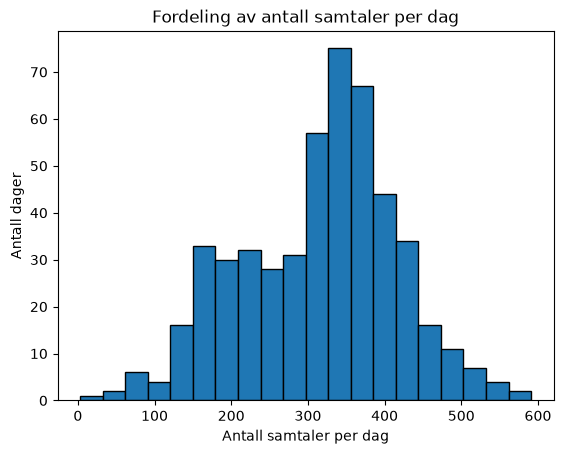

In [159]:
plt.hist(df_["antall_samtaler"], bins=20, edgecolor="black")
plt.title("Fordeling av antall samtaler per dag")
plt.xlabel("Antall samtaler per dag")
plt.ylabel("Antall dager")
plt.show()

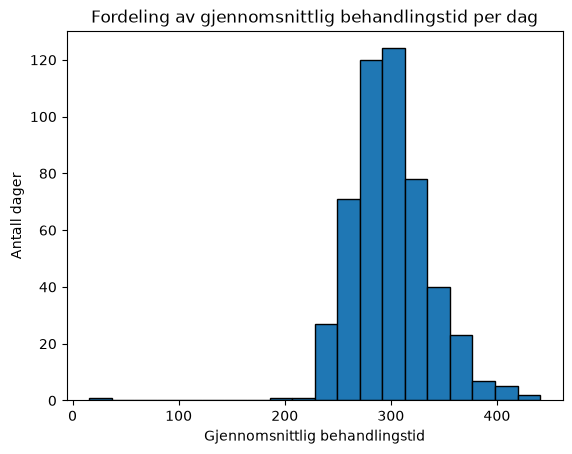

In [160]:
plt.hist(df_["behandlingstid_snitt"], bins=20, edgecolor="black")
plt.title("Fordeling av gjennomsnittlig behandlingstid per dag")
plt.xlabel("Gjennomsnittlig behandlingstid")
plt.ylabel("Antall dager")
plt.show()

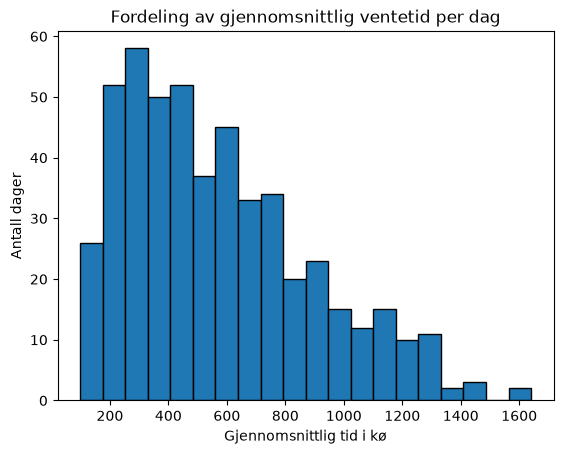

In [161]:
plt.hist(df_["tid_i_ko_snitt"], bins=20, edgecolor="black")
plt.title("Fordeling av gjennomsnittlig ventetid per dag")
plt.xlabel("Gjennomsnittlig tid i kø")
plt.ylabel("Antall dager")
plt.show()

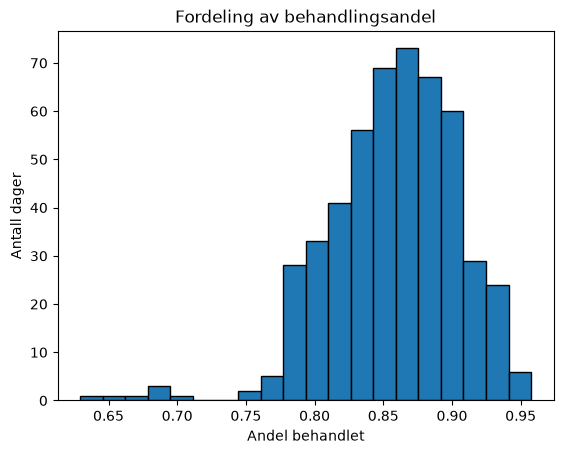

In [162]:
plt.hist(df_["behandlet_andel"], bins=20, edgecolor="black")
plt.title("Fordeling av behandlingsandel")
plt.xlabel("Andel behandlet")
plt.ylabel("Antall dager")
plt.show()

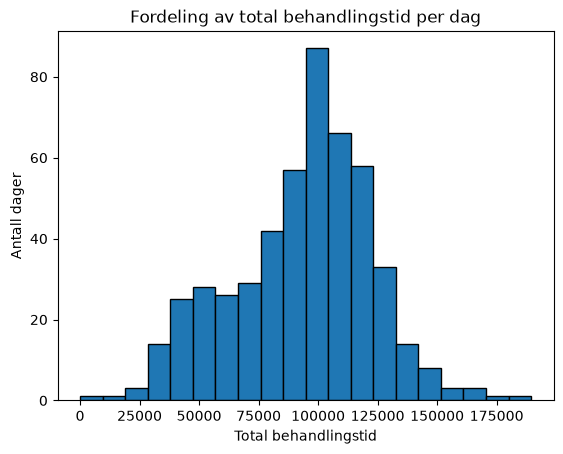

In [163]:
plt.hist(df_["total_behandlingstid"], bins=20, edgecolor="black")
plt.title("Fordeling av total behandlingstid per dag")
plt.xlabel("Total behandlingstid")
plt.ylabel("Antall dager")
plt.show()

In [164]:
print(len(df_.columns))

116


### Modellering

In [165]:
# Fjerner noen kolonner: Beholder kun 30 dager bak, fjerner fremover og 7 dager bak. 
cols_to_remove = [
    "hf_dato",
    "antall_nye_kunder_b7_mpb01_ny",
    "antall_nye_kunder_f30_mpb01_ny",
    "antall_nye_kunder_f7_mpb01_ny",
    "antall_hf_b7_mpb01_ny",
    "antall_hf_f30_mpb01_ny",
    "antall_hf_f7_mpb01_ny",
    "antall_nye_kunder_b7_eph01_for",
    "antall_nye_kunder_f30_eph01_for",
    "antall_nye_kunder_f7_eph01_for",
    "antall_hf_b7_eph01_for",
    "stddev_premieendring_b7_eph01_for",
    "snitt_premieendring_b7_eph01_for",
    "antall_hf_f30_eph01_for",
    "stddev_premieendring_f30_eph01_for",
    "snitt_premieendring_f30_eph01_for",
    "antall_hf_f7_eph01_for",
    "stddev_premieendring_f7_eph01_for",
    "snitt_premieendring_f7_eph01_for",
    "antall_nye_kunder_b7_eph01_ny",
    "antall_nye_kunder_f30_eph01_ny",
    "antall_nye_kunder_f7_eph01_ny",
    "antall_hf_b7_eph01_ny",
    "antall_hf_f30_eph01_ny",
    "antall_hf_f7_eph01_ny",
    "antall_nye_kunder_b7_epf01_ny",
    "antall_nye_kunder_f30_epf01_ny",
    "antall_nye_kunder_f7_epf01_ny",
    "antall_hf_b7_epf01_ny",
    "antall_hf_f30_epf01_ny",
    "antall_hf_f7_epf01_ny",
    "antall_nye_kunder_b7_epf01_for",
    "antall_nye_kunder_f30_epf01_for",
    "antall_nye_kunder_f7_epf01_for",
    "antall_hf_b7_epf01_for",
    "stddev_premieendring_b7_epf01_for",
    "snitt_premieendring_b7_epf01_for",
    "antall_hf_f30_epf01_for",
    "stddev_premieendring_f30_epf01_for",
    "snitt_premieendring_f30_epf01_for",
    "antall_hf_f7_epf01_for",
    "stddev_premieendring_f7_epf01_for",
    "snitt_premieendring_f7_epf01_for",
    "antall_nye_kunder_b7_upr01_ny",
    "antall_nye_kunder_f30_upr01_ny",
    "antall_nye_kunder_f7_upr01_ny",
    "antall_hf_b7_upr01_ny",
    "antall_hf_f30_upr01_ny",
    "antall_hf_f7_upr01_ny",
    "antall_nye_kunder_b7_mpb01_for",
    "antall_nye_kunder_f30_mpb01_for",
    "antall_nye_kunder_f7_mpb01_for",
    "antall_hf_b7_mpb01_for",
    "stddev_premieendring_b7_mpb01_for",
    "snitt_premieendring_b7_mpb01_for",
    "antall_hf_f30_mpb01_for",
    "stddev_premieendring_f30_mpb01_for",
    "snitt_premieendring_f30_mpb01_for",
    "antall_hf_f7_mpb01_for",
    "stddev_premieendring_f7_mpb01_for",
    "snitt_premieendring_f7_mpb01_for",
    "antall_nye_kunder_b7_upr01_for",
    "antall_nye_kunder_f30_upr01_for",
    "antall_nye_kunder_f7_upr01_for",
    "antall_hf_b7_upr01_for",
    "stddev_premieendring_b7_upr01_for",
    "snitt_premieendring_b7_upr01_for",
    "antall_hf_f30_upr01_for",
    "stddev_premieendring_f30_upr01_for",
    "snitt_premieendring_f30_upr01_for",
    "antall_hf_f7_upr01_for",
    "stddev_premieendring_f7_upr01_for",
    "snitt_premieendring_f7_upr01_for"
]
df_ = df_.drop(columns=cols_to_remove)

In [166]:
df_.tail()
# df_.columns

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,antall_nye_kunder_b30_mpb01_ny,antall_hf_b30_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_hf_b30_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_hf_b30_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_hf_b30_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
495,2026-05-27,331,0.864048,363.534743,351.930514,116489,129.383686,42826,667,3703,146.0,5187.0,4.545016,1.101146,146.0,1284.0,25.0,232.0,25.0,1001.0,1.512927,1.109272,132,719,667.0,6710.0,9.490671,1.102211,132.0,2636.0,6.225303,1.070400,2026,2,5,22,3,27,0,None,0,0,0
496,2026-05-28,360,0.880556,495.938889,311.911111,112288,119.072222,42866,663,3696,144.0,5181.0,4.547289,1.101513,144.0,1294.0,25.0,236.0,25.0,994.0,1.518213,1.108412,137,735,663.0,6704.0,9.511880,1.102288,137.0,2633.0,6.229535,1.071262,2026,2,5,22,4,28,0,None,0,0,0
497,2026-05-29,302,0.937086,231.675497,330.860927,99920,141.675497,42786,686,3785,149.0,5206.0,4.536355,1.102686,149.0,1350.0,24.0,240.0,24.0,999.0,1.514422,1.109210,140,757,686.0,6717.0,9.533914,1.102922,140.0,2638.0,6.197758,1.070495,2026,2,5,22,5,29,0,None,0,0,0
498,2026-06-01,364,0.648352,289.620879,232.563187,84653,98.557692,35875,663,3660,145.0,4883.0,4.694689,1.103755,145.0,1317.0,19.0,223.0,19.0,910.0,1.586258,1.110503,136,720,663.0,6418.0,9.543133,1.102779,136.0,2521.0,6.351481,1.070159,2026,2,6,23,1,1,0,None,0,0,0
499,2026-06-02,439,0.685649,376.136674,264.995444,116333,104.482916,45868,676,3742,156.0,5056.0,4.935330,1.102536,156.0,1408.0,19.0,229.0,19.0,960.0,1.544884,1.107675,145,754,676.0,6574.0,9.350555,1.102396,145.0,2592.0,6.272551,1.069914,2026,2,6,23,2,2,0,None,0,0,0


Importer statsmodels

In [167]:
import statsmodels.api as sm
import statsmodels.formula.api as smf



Repons: total behandlingstid. (Etterbehandling er IKKE inludert her!!)

In [168]:
model_ = smf.glm(
    formula = "total_behandlingstid ~ C(ukedag) + C(aar) + C(kvartal) + C(er_dag_foer_helligdag) + C(er_dag_etter_helligdag) + antall_nye_kunder_b30_mpb01_ny + antall_hf_b30_mpb01_ny + antall_nye_kunder_b30_eph01_for + antall_hf_b30_eph01_for + stddev_premieendring_b30_eph01_for + snitt_premieendring_b30_eph01_for + antall_nye_kunder_b30_eph01_ny + antall_hf_b30_eph01_ny + antall_nye_kunder_b30_epf01_ny + antall_hf_b30_epf01_ny + antall_nye_kunder_b30_epf01_for + antall_hf_b30_epf01_for + stddev_premieendring_b30_epf01_for + snitt_premieendring_b30_epf01_for + antall_nye_kunder_b30_upr01_ny + antall_hf_b30_upr01_ny + antall_nye_kunder_b30_mpb01_for + antall_hf_b30_mpb01_for + stddev_premieendring_b30_mpb01_for + snitt_premieendring_b30_mpb01_for + antall_nye_kunder_b30_upr01_for + antall_hf_b30_upr01_for + stddev_premieendring_b30_upr01_for + snitt_premieendring_b30_upr01_for",
    data = df_,
    family=sm.families.Gaussian()
).fit()

print(model_.summary())

                  Generalized Linear Model Regression Results                   
Dep. Variable:     total_behandlingstid   No. Observations:                  456
Model:                              GLM   Df Residuals:                      423
Model Family:                  Gaussian   Df Model:                           32
Link Function:                 Identity   Scale:                      4.8809e+08
Method:                            IRLS   Log-Likelihood:                -5191.3
Date:                  Tue, 30 Jun 2026   Deviance:                   2.0646e+11
Time:                          10:35:01   Pearson chi2:                 2.06e+11
No. Iterations:                       3   Pseudo R-squ. (CS):             0.5877
Covariance Type:              nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

Antall samtaler (poisson?)

In [169]:
model_n = smf.glm(
    formula = "antall_samtaler ~ C(ukedag) + C(aar) + C(kvartal) + C(er_dag_foer_helligdag) + C(er_dag_etter_helligdag) + antall_nye_kunder_b30_mpb01_ny + antall_hf_b30_mpb01_ny + antall_nye_kunder_b30_eph01_for + antall_hf_b30_eph01_for + stddev_premieendring_b30_eph01_for + snitt_premieendring_b30_eph01_for + antall_nye_kunder_b30_eph01_ny + antall_hf_b30_eph01_ny + antall_nye_kunder_b30_epf01_ny + antall_hf_b30_epf01_ny + antall_nye_kunder_b30_epf01_for + antall_hf_b30_epf01_for + stddev_premieendring_b30_epf01_for + snitt_premieendring_b30_epf01_for + antall_nye_kunder_b30_upr01_ny + antall_hf_b30_upr01_ny + antall_nye_kunder_b30_mpb01_for + antall_hf_b30_mpb01_for + stddev_premieendring_b30_mpb01_for + snitt_premieendring_b30_mpb01_for + antall_nye_kunder_b30_upr01_for + antall_hf_b30_upr01_for + stddev_premieendring_b30_upr01_for + snitt_premieendring_b30_upr01_for",
    data = df_,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print(model_n.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:        antall_samtaler   No. Observations:                  456
Model:                            GLM   Df Residuals:                      423
Model Family:                 Poisson   Df Model:                           32
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6112.8
Date:                Tue, 30 Jun 2026   Deviance:                       8797.8
Time:                        10:35:01   Pearson chi2:                 8.35e+03
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

### Legge til værdata/momentum-effekt

In [170]:
df_.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,antall_nye_kunder_b30_mpb01_ny,antall_hf_b30_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_hf_b30_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_hf_b30_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_hf_b30_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,501,2900,96.0,4921.0,7.780343,1.119475,96.0,961.0,13.0,176.0,13.0,988.0,5.220043,1.076235,105,610,501.0,6558.0,7.516885,1.185686,105.0,2338.0,1.935644,1.032337,2024,2,6,23,1,3,0,None,0,0,0
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,502,2907,89.0,4949.0,7.758312,1.121448,89.0,936.0,11.0,166.0,11.0,996.0,5.199079,1.076031,102,601,502.0,6586.0,7.459350,1.185899,102.0,2343.0,1.946560,1.032964,2024,2,6,23,2,4,0,None,0,0,0
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,488,2880,85.0,4947.0,7.759890,1.121574,85.0,920.0,10.0,158.0,10.0,1023.0,5.130114,1.075870,104,606,488.0,6599.0,7.504770,1.186168,104.0,2356.0,1.941469,1.033941,2024,2,6,23,3,5,0,None,0,0,0
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623,474,2844,87.0,4975.0,7.738009,1.122787,87.0,925.0,9.0,155.0,9.0,1027.0,6.564680,1.081112,103,592,474.0,6627.0,7.799477,1.187572,103.0,2371.0,2.172918,1.034799,2024,2,6,23,4,6,0,None,0,0,0
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548,481,2890,87.0,4989.0,8.028814,1.123380,87.0,946.0,9.0,155.0,9.0,1024.0,6.574265,1.081179,105,603,481.0,6644.0,7.754416,1.187596,105.0,2373.0,2.172067,1.035438,2024,2,6,23,5,7,0,None,0,0,0


In [171]:
# Read temperatur data
temperatur = pd.read_csv("../../data/temperatur_oslo.csv", delimiter=";")
temperatur.columns = temperatur.columns.str.lower()
# Fiks tid-format
temperatur["tid(norsk normaltid)"]= pd.to_datetime(temperatur["tid(norsk normaltid)"], format="%d.%m.%Y").dt.date
# Fiks datatype
temperatur["maksimumstemperatur (døgn)"] = temperatur["maksimumstemperatur (døgn)"].str.replace(",", ".", regex=True).astype(float)
temperatur["middeltemperatur (døgn)"] = temperatur["middeltemperatur (døgn)"].str.replace(",", ".", regex=True).astype(float)
temperatur.head()

,navn,stasjon,tid(norsk normaltid),middeltemperatur (døgn),maksimumstemperatur (døgn)
0,Oslo - Bygdøy Ii,SN18810,2024-06-03,19.0,25.1
1,Oslo - Bygdøy Ii,SN18810,2024-06-04,15.1,19.2
2,Oslo - Bygdøy Ii,SN18810,2024-06-05,13.1,17.5
3,Oslo - Bygdøy Ii,SN18810,2024-06-06,11.6,17.7
4,Oslo - Bygdøy Ii,SN18810,2024-06-07,11.0,16.8


In [172]:
# Merge kundedata med temperatur
df_ext = pd.merge(df_, temperatur, left_on="ankomst_dato", right_on="tid(norsk normaltid)", how="left")
# Fjern unødvendige kolonner
dropcols = ["navn", "stasjon", "tid(norsk normaltid)"]
df_ext = df_ext.drop(columns=dropcols)
# Endre navn på kolonner
df_ext = df_ext.rename(columns={"maksimumstemperatur (døgn)": "maksimumstemperatur", "middeltemperatur (døgn)": "middeltemperatur"})
df_ext.head()

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,antall_nye_kunder_b30_mpb01_ny,antall_hf_b30_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_hf_b30_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_hf_b30_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_hf_b30_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag,middeltemperatur,maksimumstemperatur
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,501,2900,96.0,4921.0,7.780343,1.119475,96.0,961.0,13.0,176.0,13.0,988.0,5.220043,1.076235,105,610,501.0,6558.0,7.516885,1.185686,105.0,2338.0,1.935644,1.032337,2024,2,6,23,1,3,0,None,0,0,0,19.0,25.1
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,502,2907,89.0,4949.0,7.758312,1.121448,89.0,936.0,11.0,166.0,11.0,996.0,5.199079,1.076031,102,601,502.0,6586.0,7.459350,1.185899,102.0,2343.0,1.946560,1.032964,2024,2,6,23,2,4,0,None,0,0,0,15.1,19.2
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,488,2880,85.0,4947.0,7.759890,1.121574,85.0,920.0,10.0,158.0,10.0,1023.0,5.130114,1.075870,104,606,488.0,6599.0,7.504770,1.186168,104.0,2356.0,1.941469,1.033941,2024,2,6,23,3,5,0,None,0,0,0,13.1,17.5
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623,474,2844,87.0,4975.0,7.738009,1.122787,87.0,925.0,9.0,155.0,9.0,1027.0,6.564680,1.081112,103,592,474.0,6627.0,7.799477,1.187572,103.0,2371.0,2.172918,1.034799,2024,2,6,23,4,6,0,None,0,0,0,11.6,17.7
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548,481,2890,87.0,4989.0,8.028814,1.123380,87.0,946.0,9.0,155.0,9.0,1024.0,6.574265,1.081179,105,603,481.0,6644.0,7.754416,1.187596,105.0,2373.0,2.172067,1.035438,2024,2,6,23,5,7,0,None,0,0,0,11.0,16.8


In [173]:

print(df_ext.columns)
df_ext.head()

Index(['ankomst_dato', 'antall_samtaler', 'behandlet_andel', 'tid_i_ko_snitt',
       'behandlingstid_snitt', 'total_behandlingstid',
       'etterbehandligstid_snitt', 'total_etterbehandligstid',
       'antall_nye_kunder_b30_mpb01_ny', 'antall_hf_b30_mpb01_ny',
       'antall_nye_kunder_b30_eph01_for', 'antall_hf_b30_eph01_for',
       'stddev_premieendring_b30_eph01_for',
       'snitt_premieendring_b30_eph01_for', 'antall_nye_kunder_b30_eph01_ny',
       'antall_hf_b30_eph01_ny', 'antall_nye_kunder_b30_epf01_ny',
       'antall_hf_b30_epf01_ny', 'antall_nye_kunder_b30_epf01_for',
       'antall_hf_b30_epf01_for', 'stddev_premieendring_b30_epf01_for',
       'snitt_premieendring_b30_epf01_for', 'antall_nye_kunder_b30_upr01_ny',
       'antall_hf_b30_upr01_ny', 'antall_nye_kunder_b30_mpb01_for',
       'antall_hf_b30_mpb01_for', 'stddev_premieendring_b30_mpb01_for',
       'snitt_premieendring_b30_mpb01_for', 'antall_nye_kunder_b30_upr01_for',
       'antall_hf_b30_upr01_for', 'stdde

,ankomst_dato,antall_samtaler,behandlet_andel,tid_i_ko_snitt,behandlingstid_snitt,total_behandlingstid,etterbehandligstid_snitt,total_etterbehandligstid,antall_nye_kunder_b30_mpb01_ny,antall_hf_b30_mpb01_ny,antall_nye_kunder_b30_eph01_for,antall_hf_b30_eph01_for,stddev_premieendring_b30_eph01_for,snitt_premieendring_b30_eph01_for,antall_nye_kunder_b30_eph01_ny,antall_hf_b30_eph01_ny,antall_nye_kunder_b30_epf01_ny,antall_hf_b30_epf01_ny,antall_nye_kunder_b30_epf01_for,antall_hf_b30_epf01_for,stddev_premieendring_b30_epf01_for,snitt_premieendring_b30_epf01_for,antall_nye_kunder_b30_upr01_ny,antall_hf_b30_upr01_ny,antall_nye_kunder_b30_mpb01_for,antall_hf_b30_mpb01_for,stddev_premieendring_b30_mpb01_for,snitt_premieendring_b30_mpb01_for,antall_nye_kunder_b30_upr01_for,antall_hf_b30_upr01_for,stddev_premieendring_b30_upr01_for,snitt_premieendring_b30_upr01_for,aar,kvartal,maaned,ukenummer,ukedag,dag_i_maaned,er_helg,helligdag,er_helligdag,er_dag_foer_helligdag,er_dag_etter_helligdag,middeltemperatur,maksimumstemperatur
0,2024-06-03,181,0.850829,274.342541,281.049724,50870,130.419890,23606,501,2900,96.0,4921.0,7.780343,1.119475,96.0,961.0,13.0,176.0,13.0,988.0,5.220043,1.076235,105,610,501.0,6558.0,7.516885,1.185686,105.0,2338.0,1.935644,1.032337,2024,2,6,23,1,3,0,None,0,0,0,19.0,25.1
1,2024-06-04,408,0.828431,732.632353,280.009804,114244,121.987745,49771,502,2907,89.0,4949.0,7.758312,1.121448,89.0,936.0,11.0,166.0,11.0,996.0,5.199079,1.076031,102,601,502.0,6586.0,7.459350,1.185899,102.0,2343.0,1.946560,1.032964,2024,2,6,23,2,4,0,None,0,0,0,15.1,19.2
2,2024-06-05,294,0.782313,650.248299,258.166667,75901,97.272109,28598,488,2880,85.0,4947.0,7.759890,1.121574,85.0,920.0,10.0,158.0,10.0,1023.0,5.130114,1.075870,104,606,488.0,6599.0,7.504770,1.186168,104.0,2356.0,1.941469,1.033941,2024,2,6,23,3,5,0,None,0,0,0,13.1,17.5
3,2024-06-06,313,0.808307,447.830671,294.220447,92091,91.447284,28623,474,2844,87.0,4975.0,7.738009,1.122787,87.0,925.0,9.0,155.0,9.0,1027.0,6.564680,1.081112,103,592,474.0,6627.0,7.799477,1.187572,103.0,2371.0,2.172918,1.034799,2024,2,6,23,4,6,0,None,0,0,0,11.6,17.7
4,2024-06-07,371,0.867925,791.533693,301.137466,111722,133.552561,49548,481,2890,87.0,4989.0,8.028814,1.123380,87.0,946.0,9.0,155.0,9.0,1024.0,6.574265,1.081179,105,603,481.0,6644.0,7.754416,1.187596,105.0,2373.0,2.172067,1.035438,2024,2,6,23,5,7,0,None,0,0,0,11.0,16.8


### Sjekker effekten av temperatur på antall samtaler om dagen:

                 Generalized Linear Model Regression Results                  
Dep. Variable:        antall_samtaler   No. Observations:                  500
Model:                            GLM   Df Residuals:                      498
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -10674.
Date:                Tue, 30 Jun 2026   Deviance:                       17589.
Time:                        10:36:49   Pearson chi2:                 1.63e+04
No. Iterations:                     4   Pseudo R-squ. (CS):             0.4275
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               5.8094    

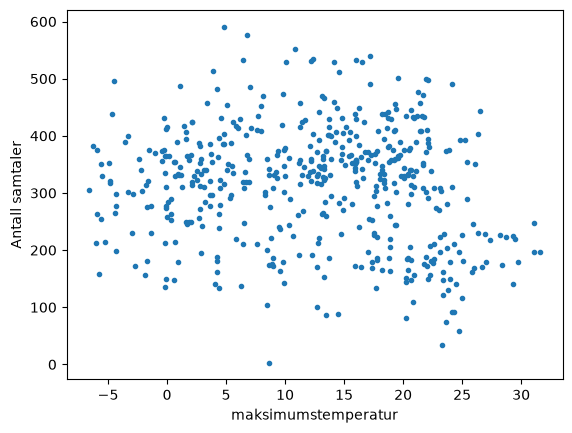

In [ ]:
model_temp= smf.glm(
    formula = "antall_samtaler ~ maksimumstemperatur",
    data = df_ext,
    family=sm.families.Poisson(link=sm.families.links.Log())
).fit()

print(model_temp.summary())

plt.scatter(df_ext["maksimumstemperatur"], df_ext["antall_samtaler"], marker = ".")
plt.xlabel("maksimumstemperatur")
plt.ylabel("Antall samtaler")
plt.title("Temperatur vs. antall samtaler")
plt.show()

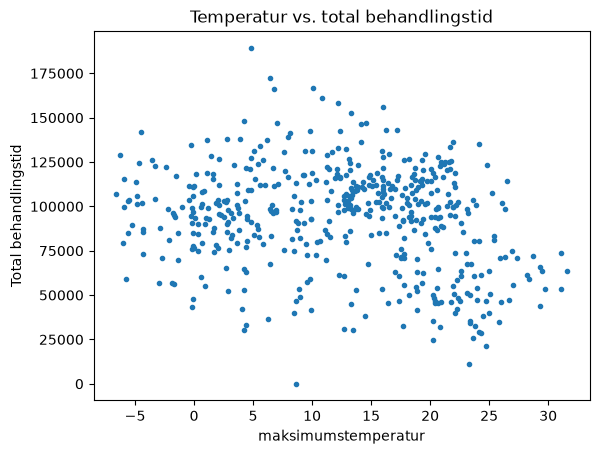

In [177]:
plt.scatter(df_ext["maksimumstemperatur"], df_ext["total_behandlingstid"], marker = ".")
plt.xlabel("maksimumstemperatur")
plt.ylabel("Total behandlingstid")
plt.title("Temperatur vs. total behandlingstid")
plt.show()